Mounted at /content/drive
  Ready: /content/drive/MyDrive/PhishingClassifier
  Ready: /content/drive/MyDrive/PhishingClassifier/model
  Ready: /content/drive/MyDrive/PhishingClassifier/logs
  Ready: /content/drive/MyDrive/PhishingClassifier/plots

LOADING DATASET
Trying cybersectony/PhishingEmailDetectionv2.0 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/27.9M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/3.17M [00:00<?, ?B/s]

...

train.jsonl:   0%|          | 0.00/101M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/6.27M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/31716 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

  Columns      : ['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date']
  Rows loaded  : 31716

CLEANING DATA
  Before cleaning : 31716
  After cleaning  : 28786
  Legitimate (0)  : 14977
  Phishing   (1)  : 13809

BALANCING CLASSES
  Per class  : 13809
  Total rows : 27618

SPLITTING DATA
  Train : 19332
  Val   : 4143
  Test  : 4143

SAVING CSV FILES

VERIFYING SAVED FILES
  OK : train.csv  (27843.8 KB  |  19332 rows)
  OK : val.csv  (6444.4 KB  |  4143 rows)
  OK : test.csv  (5968.8 KB  |  4143 rows)

GENERATING EDA PLOTS
  text_len — min:16  max:228368  mean:1486


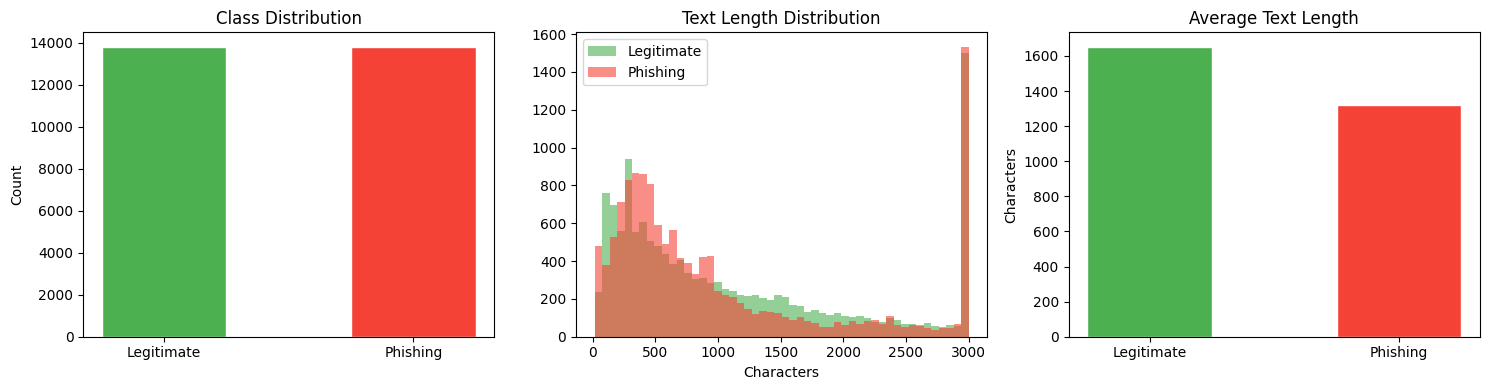

  EDA plot saved.

STEP 2 COMPLETE
All CSV files saved and verified.
Proceed to 03_tokenisation.py


In [2]:
# the errored one ============================================================
# STEP 2 — Data Preparation (FULLY REWRITTEN)
# Loads datasets, cleans, balances, splits, and VERIFIES
# that all 3 CSV files are saved to Drive before exiting.
# ============================================================

import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from google.colab import drive

# ============================================================
# 2.0  Mount Drive + Create Folders (ALWAYS run first)
# ============================================================
drive.mount("/content/drive", force_remount=True)

SAVE_DIR = "/content/drive/MyDrive/PhishingClassifier"

for folder in [SAVE_DIR, f"{SAVE_DIR}/model", f"{SAVE_DIR}/logs", f"{SAVE_DIR}/plots"]:
    os.makedirs(folder, exist_ok=True)
    print(f"  Ready: {folder}")

# ============================================================
# 2.1  Load Dataset
# ============================================================
# Using ONE reliable source that always works with no scripts.
# cybersectony/PhishingEmailDetectionv2.0
#   columns : 'content' (text), 'labels' (0=legit, 1=phish, 2=legit_url, 3=phish_url)
#   we keep only labels 0 and 1 (email rows only)

print("\n" + "=" * 50)
print("LOADING DATASET")
print("=" * 50)

loaded = False

# --- Attempt 1: cybersectony ---
try:
    print("Trying cybersectony/PhishingEmailDetectionv2.0 ...")
    ds = load_dataset("cybersectony/PhishingEmailDetectionv2.0", split="train")
    df_raw = pd.DataFrame(ds)
    print(f"  Columns      : {df_raw.columns.tolist()}")
    print(f"  Label values : {df_raw['labels'].value_counts().to_dict()}")
    df_raw = df_raw[df_raw["labels"].isin([0, 1])][["content", "labels"]].copy()
    df_raw.columns = ["text", "label"]
    df_raw["label"] = df_raw["label"].astype(int)
    print(f"  Rows loaded  : {len(df_raw)}")
    loaded = True
except Exception as e:
    print(f"  FAILED: {e}")

# --- Attempt 2: SetFit/enron_spam ---
if not loaded:
    try:
        print("Trying SetFit/enron_spam ...")
        ds = load_dataset("SetFit/enron_spam", split="train")
        df_raw = pd.DataFrame(ds)
        print(f"  Columns      : {df_raw.columns.tolist()}")
        df_raw = df_raw[["text", "label"]].copy()
        df_raw["label"] = df_raw["label"].astype(int)
        print(f"  Rows loaded  : {len(df_raw)}")
        loaded = True
    except Exception as e:
        print(f"  FAILED: {e}")

# --- Attempt 3: ealvaradob emails_reduced ---
if not loaded:
    try:
        print("Trying ealvaradob/phishing-dataset ...")
        ds = load_dataset(
            "ealvaradob/phishing-dataset",
            "emails_reduced",
            trust_remote_code=True
        )
        df_raw = pd.DataFrame(ds["train"])
        print(f"  Columns      : {df_raw.columns.tolist()}")
        df_raw = df_raw[["text", "label"]].copy()
        df_raw["label"] = df_raw["label"].astype(int)
        print(f"  Rows loaded  : {len(df_raw)}")
        loaded = True
    except Exception as e:
        print(f"  FAILED: {e}")

if not loaded:
    raise RuntimeError("All dataset sources failed. Check your internet connection.")

# ============================================================
# 2.2  Clean Data
# ============================================================
print("\n" + "=" * 50)
print("CLEANING DATA")
print("=" * 50)

before = len(df_raw)
df_raw["text"]  = df_raw["text"].astype(str).str.strip()
df_raw["label"] = pd.to_numeric(df_raw["label"], errors="coerce")
df_raw = df_raw[df_raw["text"].str.len() > 15]
df_raw = df_raw.drop_duplicates(subset=["text"])
df_raw = df_raw.dropna(subset=["text", "label"])
df_raw["label"] = df_raw["label"].astype(int)
df_raw = df_raw.reset_index(drop=True)

print(f"  Before cleaning : {before}")
print(f"  After cleaning  : {len(df_raw)}")
print(f"  Legitimate (0)  : {(df_raw['label'] == 0).sum()}")
print(f"  Phishing   (1)  : {(df_raw['label'] == 1).sum()}")

# ============================================================
# 2.3  Balance Classes
# ============================================================
print("\n" + "=" * 50)
print("BALANCING CLASSES")
print("=" * 50)

phish    = df_raw[df_raw["label"] == 1]
legit    = df_raw[df_raw["label"] == 0]
min_size = min(len(phish), len(legit))

phish = phish.sample(min_size, random_state=42)
legit = legit.sample(min_size, random_state=42)

df_balanced = pd.concat([phish, legit]) \
                .sample(frac=1, random_state=42) \
                .reset_index(drop=True)

print(f"  Per class  : {min_size}")
print(f"  Total rows : {len(df_balanced)}")

# ============================================================
# 2.4  Split into Train / Val / Test (70 / 15 / 15)
# ============================================================
print("\n" + "=" * 50)
print("SPLITTING DATA")
print("=" * 50)

train_df, temp_df = train_test_split(
    df_balanced, test_size=0.30,
    random_state=42, stratify=df_balanced["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    random_state=42, stratify=temp_df["label"]
)

print(f"  Train : {len(train_df)}")
print(f"  Val   : {len(val_df)}")
print(f"  Test  : {len(test_df)}")

# ============================================================
# 2.5  Save CSVs to Drive
# ============================================================
print("\n" + "=" * 50)
print("SAVING CSV FILES")
print("=" * 50)

train_path = f"{SAVE_DIR}/train.csv"
val_path   = f"{SAVE_DIR}/val.csv"
test_path  = f"{SAVE_DIR}/test.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path,     index=False)
test_df.to_csv(test_path,   index=False)

# ============================================================
# 2.6  VERIFY Files Were Actually Saved
# ============================================================
print("\n" + "=" * 50)
print("VERIFYING SAVED FILES")
print("=" * 50)

all_good = True
for path, name in [(train_path, "train.csv"), (val_path, "val.csv"), (test_path, "test.csv")]:
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        rows = pd.read_csv(path).shape[0]
        print(f"  OK : {name}  ({size:.1f} KB  |  {rows} rows)")
    else:
        print(f"  FAILED : {name} was NOT saved!")
        all_good = False

if not all_good:
    raise RuntimeError("Some CSV files failed to save. Check Drive storage and permissions.")

# ============================================================
# 2.7  EDA Plots
# ============================================================
print("\n" + "=" * 50)
print("GENERATING EDA PLOTS")
print("=" * 50)

df_balanced["text_len"] = df_balanced["text"].astype(str).str.len()

print(f"  text_len — min:{df_balanced['text_len'].min()}  "
      f"max:{df_balanced['text_len'].max()}  "
      f"mean:{df_balanced['text_len'].mean():.0f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Class distribution
counts = df_balanced["label"].value_counts()
axes[0].bar(
    ["Legitimate", "Phishing"],
    [counts.get(0, 0), counts.get(1, 0)],
    color=["#4CAF50", "#F44336"],
    edgecolor="white", width=0.5
)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")

# Plot 2 — Text length histogram
for label, color, name in [(0, "#4CAF50", "Legitimate"), (1, "#F44336", "Phishing")]:
    subset = df_balanced[df_balanced["label"] == label]["text_len"].dropna()
    subset = subset[subset > 0].clip(upper=3000)
    if len(subset) > 0:
        axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=name)
axes[1].set_title("Text Length Distribution")
axes[1].set_xlabel("Characters")
axes[1].legend()

# Plot 3 — Average text length
avg = df_balanced.groupby("label")["text_len"].mean()
axes[2].bar(
    ["Legitimate", "Phishing"],
    [avg.get(0, 0), avg.get(1, 0)],
    color=["#4CAF50", "#F44336"],
    edgecolor="white", width=0.5
)
axes[2].set_title("Average Text Length")
axes[2].set_ylabel("Characters")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/plots/eda.png", dpi=150)
plt.show()
print(f"  EDA plot saved.")

print("\n" + "=" * 50)
print("STEP 2 COMPLETE")
print("All CSV files saved and verified.")
print("Proceed to 03_tokenisation.py")
print("=" * 50)

Mounted at /content/drive
Save directory ready: /content/drive/MyDrive/PhishingClassifier

LOADING DATASET
Trying cybersectony/PhishingEmailDetectionv2.0 ...
  Columns : ['content', 'label']
  Failed  : 'labels'
Trying SetFit/enron_spam ...


Repo card metadata block was not found. Setting CardData to empty.


  Columns : ['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date']
  Loaded  : 31716 rows

CLEANING
  Before : 31716
  After  : 28786
  Label 0 (legit)   : 14977
  Label 1 (phishing): 13809

BALANCING
  Per class  : 13809
  Total rows : 27618

SPLITTING
  Train : 19332
  Val   : 4143
  Test  : 4143

SAVING CSV FILES
  OK : train.csv  (27844 KB  |  19332 rows)
  OK : val.csv  (6444 KB  |  4143 rows)
  OK : test.csv  (5969 KB  |  4143 rows)

EDA PLOTS
  text_len — min:16  max:228368  mean:1486


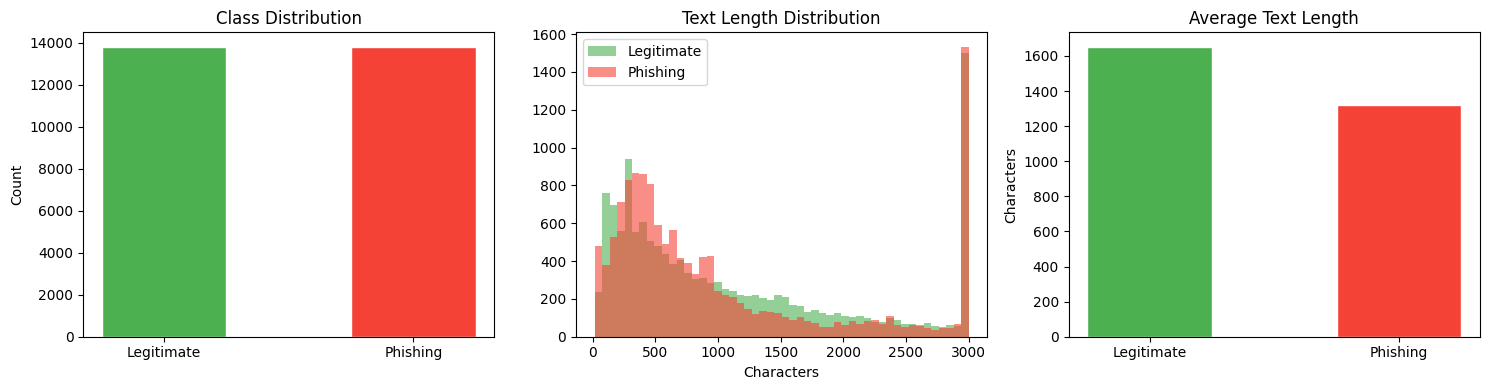


STEP 2 COMPLETE — all files saved and verified.
Proceed to 03_tokenisation.py


In [3]:
# ============================================================
# STEP 2 — Data Preparation
# Loads dataset, cleans, balances, splits into train/val/test,
# saves CSVs to Drive, and verifies the files were saved.
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from google.colab import drive

# ============================================================
# 2.0  Mount Drive + Folders (run every session)
# ============================================================
drive.mount("/content/drive", force_remount=True)

SAVE_DIR = "/content/drive/MyDrive/PhishingClassifier"
for folder in [SAVE_DIR,
               f"{SAVE_DIR}/model",
               f"{SAVE_DIR}/logs",
               f"{SAVE_DIR}/plots"]:
    os.makedirs(folder, exist_ok=True)
print(f"Save directory ready: {SAVE_DIR}\n")

# ============================================================
# 2.1  Load Dataset
# Three sources tried in order — first success is used.
# ============================================================
print("=" * 50)
print("LOADING DATASET")
print("=" * 50)

df_raw = None

# --- Source 1 ---
try:
    print("Trying cybersectony/PhishingEmailDetectionv2.0 ...")
    ds   = load_dataset("cybersectony/PhishingEmailDetectionv2.0", split="train")
    tmp  = pd.DataFrame(ds)
    print(f"  Columns : {tmp.columns.tolist()}")
    print(f"  Labels  : {tmp['labels'].value_counts().to_dict()}")
    tmp  = tmp[tmp["labels"].isin([0, 1])][["content", "labels"]].copy()
    tmp.columns = ["text", "label"]
    tmp["label"] = tmp["label"].astype(int)
    df_raw = tmp
    print(f"  Loaded  : {len(df_raw)} rows")
except Exception as e:
    print(f"  Failed  : {e}")

# --- Source 2 ---
if df_raw is None:
    try:
        print("Trying SetFit/enron_spam ...")
        ds   = load_dataset("SetFit/enron_spam", split="train")
        tmp  = pd.DataFrame(ds)
        print(f"  Columns : {tmp.columns.tolist()}")
        tmp  = tmp[["text", "label"]].copy()
        tmp["label"] = tmp["label"].astype(int)
        df_raw = tmp
        print(f"  Loaded  : {len(df_raw)} rows")
    except Exception as e:
        print(f"  Failed  : {e}")

# --- Source 3 ---
if df_raw is None:
    try:
        print("Trying ealvaradob/phishing-dataset ...")
        ds   = load_dataset("ealvaradob/phishing-dataset",
                            "emails_reduced",
                            trust_remote_code=True)
        tmp  = pd.DataFrame(ds["train"])
        print(f"  Columns : {tmp.columns.tolist()}")
        tmp  = tmp[["text", "label"]].copy()
        tmp["label"] = tmp["label"].astype(int)
        df_raw = tmp
        print(f"  Loaded  : {len(df_raw)} rows")
    except Exception as e:
        print(f"  Failed  : {e}")

if df_raw is None:
    raise RuntimeError("All dataset sources failed. Check your internet connection.")

# ============================================================
# 2.2  Clean
# ============================================================
print("\n" + "=" * 50)
print("CLEANING")
print("=" * 50)

before       = len(df_raw)
df_raw["text"]  = df_raw["text"].astype(str).str.strip()
df_raw["label"] = pd.to_numeric(df_raw["label"], errors="coerce")
df_raw = df_raw[df_raw["text"].str.len() > 15]
df_raw = df_raw.drop_duplicates(subset=["text"])
df_raw = df_raw.dropna(subset=["text", "label"])
df_raw["label"] = df_raw["label"].astype(int)
df_raw = df_raw.reset_index(drop=True)

print(f"  Before : {before}")
print(f"  After  : {len(df_raw)}")
print(f"  Label 0 (legit)   : {(df_raw['label'] == 0).sum()}")
print(f"  Label 1 (phishing): {(df_raw['label'] == 1).sum()}")

# ============================================================
# 2.3  Balance (50 / 50)
# ============================================================
print("\n" + "=" * 50)
print("BALANCING")
print("=" * 50)

phish    = df_raw[df_raw["label"] == 1]
legit    = df_raw[df_raw["label"] == 0]
min_size = min(len(phish), len(legit))
phish    = phish.sample(min_size, random_state=42)
legit    = legit.sample(min_size, random_state=42)

df_bal = pd.concat([phish, legit]) \
           .sample(frac=1, random_state=42) \
           .reset_index(drop=True)

print(f"  Per class  : {min_size}")
print(f"  Total rows : {len(df_bal)}")

# ============================================================
# 2.4  Split 70 / 15 / 15
# ============================================================
print("\n" + "=" * 50)
print("SPLITTING")
print("=" * 50)

train_df, temp_df = train_test_split(
    df_bal, test_size=0.30,
    random_state=42, stratify=df_bal["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    random_state=42, stratify=temp_df["label"]
)

print(f"  Train : {len(train_df)}")
print(f"  Val   : {len(val_df)}")
print(f"  Test  : {len(test_df)}")

# ============================================================
# 2.5  Save CSVs
# ============================================================
print("\n" + "=" * 50)
print("SAVING CSV FILES")
print("=" * 50)

train_df.to_csv(f"{SAVE_DIR}/train.csv", index=False)
val_df.to_csv(f"{SAVE_DIR}/val.csv",     index=False)
test_df.to_csv(f"{SAVE_DIR}/test.csv",   index=False)

# Verify each file was actually written
all_ok = True
for name in ["train.csv", "val.csv", "test.csv"]:
    path = f"{SAVE_DIR}/{name}"
    if os.path.exists(path) and os.path.getsize(path) > 0:
        rows = pd.read_csv(path).shape[0]
        size = os.path.getsize(path) / 1024
        print(f"  OK : {name}  ({size:.0f} KB  |  {rows} rows)")
    else:
        print(f"  FAILED : {name} was not saved!")
        all_ok = False

if not all_ok:
    raise RuntimeError("CSV save failed. Check your Google Drive storage.")

# ============================================================
# 2.6  EDA Plots
# ============================================================
print("\n" + "=" * 50)
print("EDA PLOTS")
print("=" * 50)

df_bal = df_bal.copy()
df_bal["text_len"] = df_bal["text"].astype(str).str.len()
print(f"  text_len — min:{df_bal['text_len'].min()}  "
      f"max:{df_bal['text_len'].max()}  "
      f"mean:{df_bal['text_len'].mean():.0f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class distribution
counts = df_bal["label"].value_counts()
axes[0].bar(["Legitimate", "Phishing"],
            [counts.get(0, 0), counts.get(1, 0)],
            color=["#4CAF50", "#F44336"], edgecolor="white", width=0.5)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")

# Text length
for lbl, col, nm in [(0, "#4CAF50", "Legitimate"), (1, "#F44336", "Phishing")]:
    s = df_bal[df_bal["label"] == lbl]["text_len"].dropna()
    s = s[s > 0].clip(upper=3000)
    if len(s) > 0:
        axes[1].hist(s, bins=50, alpha=0.6, color=col, label=nm)
axes[1].set_title("Text Length Distribution")
axes[1].set_xlabel("Characters")
axes[1].legend()

# Average length
avg = df_bal.groupby("label")["text_len"].mean()
axes[2].bar(["Legitimate", "Phishing"],
            [avg.get(0, 0), avg.get(1, 0)],
            color=["#4CAF50", "#F44336"], edgecolor="white", width=0.5)
axes[2].set_title("Average Text Length")
axes[2].set_ylabel("Characters")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/plots/eda.png", dpi=150)
plt.show()

print("\n" + "=" * 50)
print("STEP 2 COMPLETE — all files saved and verified.")
print("Proceed to 03_tokenisation.py")
print("=" * 50)